In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import classification_report, confusion_matrix


# -----------------------------
# 1) Read data
# -----------------------------
df = pd.read_csv("Profile_All_procced.csv", index_col=0)

# -----------------------------
# 2) y: label
# 你这个文件里标签列是 Group1（第一列）
# -----------------------------
le = LabelEncoder()
y = le.fit_transform(df["therapy"].astype(str).values)

# -----------------------------
# 3) X: features
# 去掉标签列 + 去掉字符串列 sample.1（如果存在）
# 并强制把所有特征转为数值（转不了的变 NaN，后面用均值填）
# -----------------------------
X_df = df.drop(columns=["therapy", "sample.1"], errors="ignore")
X = X_df.apply(pd.to_numeric, errors="coerce")  # 非数值 -> NaN

# Preprocess data: impute missing values and standardize features
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Use Random Forest to compute feature importances and select features
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X, y)

# Adjust the threshold (try a lower threshold to select more features)
custom_threshold = 0.003
selector = SelectFromModel(rf_selector, threshold=custom_threshold, prefit=True)
X_selected = selector.transform(X)
print("Number of features selected:", X_selected.shape[1])

# Use StratifiedKFold for cross-validation due to small dataset size
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Set up parameter grid for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10]
}

# Use GridSearchCV to tune Random Forest parameters
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid,
                           cv=cv,
                           scoring="accuracy")
grid_search.fit(X_selected, y)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best model
best_rf = grid_search.best_estimator_

# Perform cross-validation with the best model to get fold-wise scores
cv_scores = cross_val_score(best_rf, X_selected, y, cv=cv, scoring="accuracy")
print("Cross-validation scores for each fold:", cv_scores)



/workspace/tools/anaconda3/envs/IRnet/lib/python3.10/site-packages/sklearn/impute/_base.py:637: UserWarning: Skipping features without any observed values: ['project' 'Age' 'percent_IGH_of_Bcell' 'percent_IGK_of_Bcell'
 'percent_IGL_of_Bcell' 'TRA_mean_cdr3_length' 'TRB_mean_cdr3_length'
 'TRD_mean_cdr3_length' 'TRG_mean_cdr3_length' 'IGH_mean_cdr3_length'
 'IGK_mean_cdr3_length' 'IGL_mean_cdr3_length' 'IGHM_Shannon'
 'IGHM_Pielou_evenness' 'IGHM_Simpson' 'IGHM_Simpson_evenness'
 'IGHM_Gini_index' 'IGHM_d50' 'IGHD_Shannon' 'IGHD_Pielou_evenness'
 'IGHD_Simpson' 'IGHD_Simpson_evenness' 'IGHD_Gini_index' 'IGHD_d50'
 'IGHG12_Shannon' 'IGHG12_Pielou_evenness' 'IGHG12_Simpson'
 'IGHG12_Simpson_evenness' 'IGHG12_Gini_index' 'IGHG12_d50'
 'IGHG34_Shannon' 'IGHG34_Pielou_evenness' 'IGHG34_Simpson'
 'IGHG34_Simpson_evenness' 'IGHG34_Gini_index' 'IGHG34_d50' 'IGHE_Shannon'
 'IGHE_Pielou_evenness' 'IGHE_Simpson' 'IGHE_Simpson_evenness'
 'IGHE_Gini_index' 'IGHE_d50' 'IGHA_Shannon' 'IGHA_Pielou_eve

Number of features selected: 62
Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation accuracy: 0.8777777777777778
Cross-validation scores for each fold: [0.83333333 0.8        1.        ]


In [7]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 20
# Plot cross-validation results
plt.figure(figsize=(8, 5))
folds = np.arange(1, len(cv_scores) + 1)

# 使用 pre 颜色绘制柱状图
plt.bar(folds, cv_scores, color="#3976B0", edgecolor='black')

# 使用 post 颜色绘制均值曲线（虚线）
mean_score = np.mean(cv_scores)
plt.plot(folds, [mean_score] * len(cv_scores), linestyle='--', color="#CA8E8C", 
         label=f'Mean = {mean_score:.4f}', linewidth=4)

plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Cross-validation Accuracy per Fold")
plt.xticks(folds)
plt.legend()
plt.tight_layout()
plt.savefig("cross_validation_accuracy.pdf",dpi=300)
plt.close()
# ---------------------------
# 模型评估及分类报告
# ---------------------------
y_pred = best_rf.predict(X_selected)
print("Classification Report:")
print(classification_report(y, y_pred, target_names=le.classes_))

# ---------------------------
# 混淆矩阵图
# ---------------------------

# 生成自定义色带，从 pre 颜色到 post 颜色
custom_cmap = LinearSegmentedColormap.from_list('custom', ["#3976B0", "#CA8E8C"])

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 5))
# 利用自定义色带绘制混淆矩阵
plt.imshow(cm, interpolation='nearest', cmap=custom_cmap)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(le.classes_))
plt.xticks(tick_marks, le.classes_, rotation=45)
plt.yticks(tick_marks, le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# 在每个单元格内显示数值
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig("confusion_matrix.pdf",dpi=300)
plt.close()

Classification Report:
              precision    recall  f1-score   support

       after       1.00      1.00      1.00         8
      before       1.00      1.00      1.00         8

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [8]:
# Convert features to numeric and drop columns that are all NaN
numeric_df = df.iloc[:, 2:].apply(pd.to_numeric, errors='coerce')
numeric_df = numeric_df.dropna(axis=1, how='all')
original_feature_names = numeric_df.columns.values  # Now its length matches X's columns
X = numeric_df.values

print("Shape of X:", X.shape)
print("Number of original features:", len(original_feature_names))

# Preprocess data: impute missing values and standardize features
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train RandomForest for feature selection
from sklearn.ensemble import RandomForestClassifier
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X, y)

# Feature selection using a custom threshold
from sklearn.feature_selection import SelectFromModel
custom_threshold = 0.003
selector = SelectFromModel(rf_selector, threshold=custom_threshold, prefit=True)
X_selected = selector.transform(X)
print("Number of features selected:", X_selected.shape[1])

# Now the boolean mask from selector.get_support() should match original_feature_names length
mask = selector.get_support()
print("Mask shape:", mask.shape)
print("Length of original_feature_names:", len(original_feature_names))

# Get selected feature names
selected_feature_names = original_feature_names[mask]

# Get feature importances from a trained model (e.g., rf_selector or best_rf)
importances = rf_selector.feature_importances_
# Get importances only for the selected features
selected_importances = importances[mask]
# Sort selected features by importance (descending)
sorted_indices = np.argsort(selected_importances)[::-1]
top10_indices = sorted_indices[:20]
top10_importances = selected_importances[top10_indices]
top10_feature_names = selected_feature_names[top10_indices]

# Plot top 10 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 6))
# 使用 pre 颜色 (#3976B0) 填充，使用 post 颜色 (#CA8E8C) 作为边框
plt.bar(range(20), top10_importances, align='center', color="#3976B0")
plt.xticks(range(20), top10_feature_names, rotation=45, ha='right')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.savefig("top20_feature_importances.pdf",dpi=300)
plt.close()

Shape of X: (16, 138)
Number of original features: 138
Number of features selected: 62
Mask shape: (138,)
Length of original_feature_names: 138


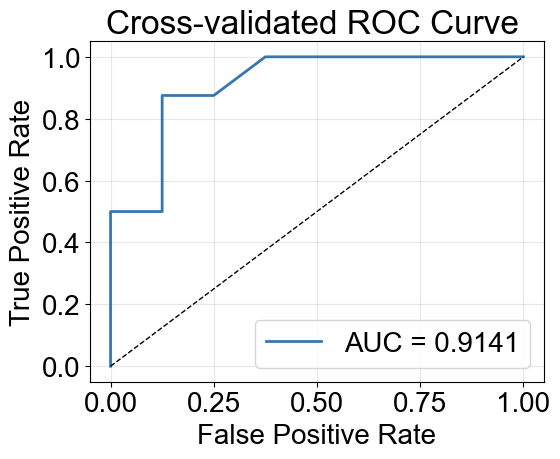

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1) 二分类标签准备（确保 y 只有两类）
# -----------------------------
# 如果你的 y 不是 0/1，而是字符串或 1/2/3 之类，请在这里先映射成 0/1
# 例子：
# y = np.array([1 if v == "Case" else 0 for v in y])

classes = np.unique(y)
assert len(classes) == 2, f"y 不是二分类，当前类别数 = {len(classes)}，classes = {classes}"

# 指定正类（正类是谁就改谁）
# 如果你的 y 已经是 0/1，这里 pos_label=1 就行
pos_label = 1
# 如果你的标签是 {0,2} 这种，就用 pos_label=2
# pos_label = classes[1]

# -----------------------------
# 2) StratifiedKFold
# -----------------------------
cv = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)

# 存储所有折的预测与真实标签（用于整体 ROC）
y_test_all = []
y_score_all = []

for train_idx, test_idx in cv.split(X_selected, y):
    X_train, X_test = X_selected[train_idx], X_selected[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf = RandomForestClassifier(**grid_search.best_params_, random_state=42)
    clf.fit(X_train, y_train)

    # 二分类 predict_proba 返回 [P(class0), P(class1)]（按 clf.classes_ 顺序）
    proba = clf.predict_proba(X_test)

    # 取“正类”的那一列概率
    pos_col = np.where(clf.classes_ == pos_label)[0][0]
    y_score = proba[:, pos_col]

    y_test_all.append(y_test)
    y_score_all.append(y_score)

y_test_all = np.concatenate(y_test_all)
y_score_all = np.concatenate(y_score_all)

# -----------------------------
# 3) ROC / AUC
# -----------------------------
fpr, tpr, _ = roc_curve(y_test_all, y_score_all, pos_label=pos_label)
roc_auc = auc(fpr, tpr)

# -----------------------------
# 4) 绘图
# -----------------------------
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, color="#3976B0", label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Cross-validated ROC Curve ")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ROC.pdf")
